# 06 · Explainability y Fair Lending — Caso 15 · Caja Rural 360

**Alcance:** sección **6.8**. Narrativa en `reports/08_explainability_fairness.md`.

Dos preguntas distintas:

1. **¿Por qué el modelo dice lo que dice?** Explicación global (qué pesa en promedio) y local (por qué esta solicitud). Para el champion la explicación es **exacta**: los puntos que pierde cada característica frente a su mejor tramo suman la diferencia de score. Para el challenger de boosting se usa **SHAP**, como pide el enunciado.
2. **¿La decisión golpea distinto a grupos sensibles?** No alcanza con no usar la variable: hay que medir el impacto de la política y comprobar que el score no funciona como proxy.

El caso pide explícitamente crecer fuera de agencias **sin excluir por falta de trazabilidad bancaria**, así que territorio, ruralidad e informalidad del ingreso son los ejes a vigilar.

| Sección | Contenido |
|---|---|
| 1 | Explicación global: puntos del scorecard y SHAP del challenger |
| 2 | Explicación local: tres clientes (aprobado, revisión, rechazado) |
| 3 | Impacto de la política por grupo: AIR y tasas de error |
| 4 | ¿El score es proxy de un atributo sensible? |
| 5 | Riesgos de discriminación indirecta, mitigantes y monitoreo |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, decision as dec, eda, evaluation as ev, fairness as fr, features, models, pipeline, scorecard as sc, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES):
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

def barras_con_ic(ax, x, tasa, lo, hi, color, ancho=0.38, desplazamiento=0.0, etiqueta=None, valores=True):
    pos = np.arange(len(x)) + desplazamiento
    ax.bar(pos, tasa, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, tasa, yerr=[np.asarray(tasa) - np.asarray(lo), np.asarray(hi) - np.asarray(tasa)],
                fmt="none", ecolor=INK_2, elinewidth=0.9, capsize=2)
    if valores:
        for p_, v in zip(pos, tasa):
            ax.text(p_, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    return pos

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


In [2]:
import joblib
raw = data.load_raw()
pop, _ = data.pd_population(raw)
fx = features.build_features(pop)
T = cfg.TARGET
dev, val, oot = (fx[fx["sample"] == s].copy() for s in cfg.SAMPLE_ORDER)
cols_in = pipeline.pipeline_input_columns()
pipe = pipeline.build_pipeline().fit(dev[cols_in])
card = sc.Scorecard.load(cfg.ROOT / "models" / "scorecard_pd_v1.json")
(cfg.ROOT / "models").mkdir(exist_ok=True)


challenger = joblib.load(cfg.ROOT / "models" / "challenger_lgbm_v1.joblib")
platt = ev.PlattCalibrator().fit(card.predict_pd(val), val[T])          # calibrador de 6.7
pd_calibrada = lambda d: platt.transform(card.predict_pd(d))
politica = dec.DecisionPolicy()                                          # umbrales de config, elegidos en §2
ttd = {a: features.build_features(raw[raw[cfg.DATE_COL].dt.year == a]) for a in (2024, 2025)}
pd_ttd = {a: pd_calibrada(t) for a, t in ttd.items()}
observado = {a: np.where(t[cfg.OUTCOME_FILTER].eq(1), t[T], np.nan) for a, t in ttd.items()}
esperado = {a: np.where(np.isnan(observado[a]), pd_ttd[a], observado[a]) for a in ttd}

decisiones = {a: politica.decide(ttd[a], pd_ttd[a], recalcular_pd=pd_calibrada) for a in ttd}
d24, t24, p24 = decisiones[2024], ttd[2024], pd_ttd[2024]
print("Política:", {k: v for k, v in politica.__dict__.items() if k != "meta"})
print("Decisiones 2024:", d24.decision.value_counts(normalize=True).round(3).to_dict())

Política: {'pd_approve_max': 0.18, 'pd_reject_min': 0.2, 'dti_auto_max': 0.45, 'dti_hard_max': 0.6, 'amount_auto_max': 20000, 'cash_share_review': 0.8, 'amount_cash_review': 10000, 'reference_rate': 0.3}
Decisiones 2024: {'APPROVE': 0.533, 'REJECT': 0.235, 'REVIEW': 0.233}


## 1. Explicación global

,min,max,rango_de_puntos,peso_relativo
variable,,,,
ahorro_sobre_monto,189,207,18,0.1636
bureau_score,169,239,70,0.6364
dti_post,185,207,22,0.2000


/home/claude/venv_tif/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/claude/venv_tif/lib/python3.12/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


,shap_medio_absoluto
bureau_score,0.6148
prior_delinquencies_24m,0.1796
dti,0.1584
ahorro_sobre_monto,0.1562
term_months,0.1206
dti_post,0.1189
monthly_debt_payment,0.1183
relationship_months,0.1128
requested_amount,0.1083
employment_tenure_months,0.0946


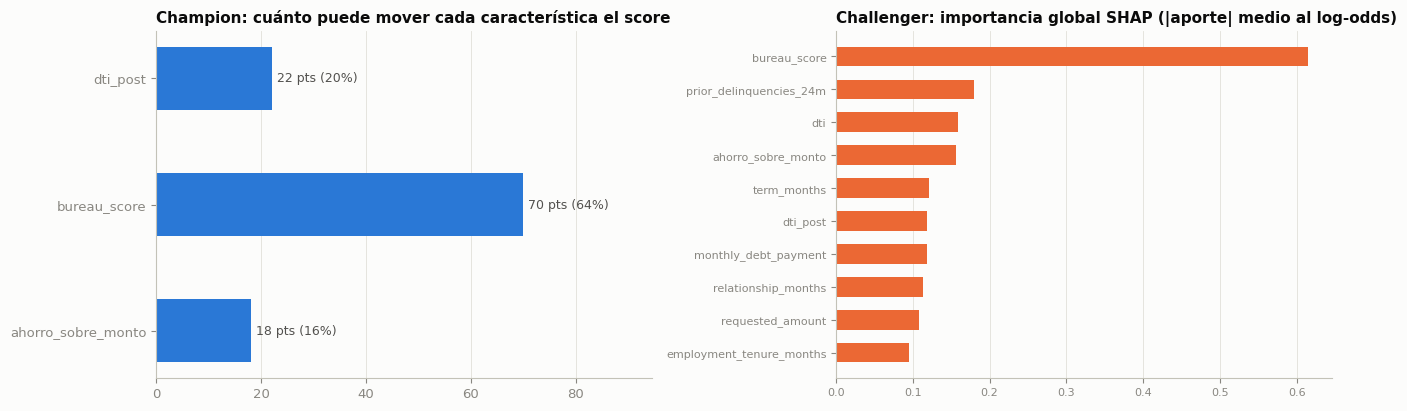

In [3]:
puntos = card.points_table()
rango = puntos[puntos.orden >= 0].groupby("variable")["puntos"].agg(["min", "max"])
rango["rango_de_puntos"] = rango["max"] - rango["min"]
rango["peso_relativo"] = rango["rango_de_puntos"] / rango["rango_de_puntos"].sum()
display(rango)

X_val = pipe.transform(val[cols_in])[challenger["columnas"]]
shap_glob = fr.shap_global(challenger["modelo"], X_val)
display(shap_glob.head(10).to_frame("shap_medio_absoluto"))
shap_glob.to_csv(cfg.TABLES / "fairness_shap_global.csv")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
axes[0].barh(rango.index, rango["rango_de_puntos"], color=BLUE, height=0.5)
for y_, v in enumerate(rango["rango_de_puntos"]):
    axes[0].text(v + 1, y_, f"{v:.0f} pts ({rango['peso_relativo'].iloc[y_]:.0%})", va="center", fontsize=9, color=INK_2)
axes[0].set_xlim(0, rango["rango_de_puntos"].max() * 1.35)
axes[0].set_title("Champion: cuánto puede mover cada característica el score"); axes[0].grid(axis="y", visible=False)
top = shap_glob.head(10)[::-1]
axes[1].barh(top.index, top.to_numpy(), color=ORANGE, height=0.6)
axes[1].set_title("Challenger: importancia global SHAP (|aporte| medio al log-odds)")
axes[1].grid(axis="y", visible=False); axes[1].tick_params(labelsize=8)
fig.tight_layout(); savefig(fig, "fig25_explicabilidad_global"); plt.show()

**Lectura.** Las dos explicaciones coinciden en el fondo y difieren en la forma. En el champion, el buró puede mover 70 puntos de score (64% del rango total), la capacidad de pago 22 (20%) y el ahorro 18 (16%): la jerarquía es explícita y auditable sin ninguna librería. En el challenger, SHAP pone al buró muy por delante del resto y después reparte aportes chicos entre mora previa, DTI, ahorro y plazo, es decir, **usa muchas variables para ganar poco**, que es lo que 6.4 anticipaba y lo que se vio en el sobreajuste de 6.6.

## 2. Explicación local: tres clientes

In [4]:
casos = {}
for etiqueta, mascara in [("Aprobado automático", d24.decision.eq("APPROVE")),
                          ("Revisión manual", d24.decision.eq("REVIEW")),
                          ("Rechazado", d24.decision.eq("REJECT"))]:
    idx = t24.index[mascara][0]
    casos[etiqueta] = idx
razones = card.reason_codes(t24.loc[list(casos.values())], n=3)
resumen = pd.DataFrame({
    "score": card.score(t24.loc[list(casos.values())]),
    "pd_calibrada": d24.loc[list(casos.values()), "pd_calibrada"].to_numpy(),   # la del motor: ya recalculada si hubo contraoferta
    "decision": d24.loc[list(casos.values()), "decision"].to_numpy(),
    "motivo": d24.loc[list(casos.values()), "motivo"].to_numpy(),
    "monto_solicitado": t24.loc[list(casos.values()), "requested_amount"].to_numpy(),
    "monto_recomendado": d24.loc[list(casos.values()), "monto_recomendado"].to_numpy(),
    "tasa_recomendada": d24.loc[list(casos.values()), "tasa_recomendada"].to_numpy(),
    "razones": [" · ".join(r) if r else "—" for r in razones]}, index=list(casos))
display(resumen)
for etiqueta, idx in casos.items():
    print(f"\n{etiqueta} (solicitud {t24.loc[idx, cfg.ID_COL]}):")
    display(fr.scorecard_local_explanation(card, t24.loc[[idx]]))
resumen.to_csv(cfg.TABLES / "fairness_casos_explicados.csv")

,score,pd_calibrada,decision,motivo,monto_solicitado,monto_recomendado,tasa_recomendada,razones
Aprobado automático,620,0.0866,APPROVE,Aprobado con contraoferta de monto por capacid...,"4,410.9400","4,300.0000",0.2405,Score de buró bajo · Carga de deuda post-crédi...
Revisión manual,635,0.0612,REVIEW,Sin ingreso declarado: verificar capacidad de ...,"6,386.5000","6,386.5000",0.1800,Ahorro bajo frente al monto solicitado · Ingre...
Rechazado,573,0.2465,REJECT,PD calibrada >= 20%,"5,507.2300",NaN,NaN,Score de buró bajo · Ahorro bajo frente al mon...



Aprobado automático (solicitud C15-000005):


,puntos,maximo_posible,puntos_perdidos,tramo
bureau_score,212,239,27,"(698, 732]"
dti_post,201,207,6,"(0.4131, 0.4926]"
ahorro_sobre_monto,207,207,0,> 0.5985



Revisión manual (solicitud C15-000010):


,puntos,maximo_posible,puntos_perdidos,tramo
ahorro_sobre_monto,197,207,10,"(0.1255, 0.5985]"
dti_post,199,207,8,Faltante / no visto
bureau_score,239,239,0,> 732



Rechazado (solicitud C15-000013):


,puntos,maximo_posible,puntos_perdidos,tramo
bureau_score,169,239,70,<= 596
ahorro_sobre_monto,197,207,10,"(0.1255, 0.5985]"
dti_post,207,207,0,<= 0.4131


In [5]:
# El challenger explica el mismo caso rechazado con SHAP: mismo diagnóstico, otra herramienta.
idx = casos["Rechazado"]
x_caso = pipe.transform(t24.loc[[idx]][cols_in])[challenger["columnas"]]
local = fr.shap_local(challenger["modelo"], x_caso)
display(local.head(6).to_frame("aporte_shap_al_log_odds"))

/home/claude/venv_tif/lib/python3.12/site-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


,aporte_shap_al_log_odds
bureau_score,0.8697
prior_delinquencies_24m,-0.1524
dti_post,-0.1402
dti,-0.1384
term_months,-0.1098
ahorro_sobre_monto,0.1011


**Lectura.** La explicación del champion es una resta, no una aproximación: el rechazado pierde 70 puntos por buró, 22 por capacidad y 18 por ahorro frente al mejor tramo posible, y esas tres líneas **son** su score. El challenger, con SHAP, llega al mismo orden de razones para el mismo cliente, pero con una atribución estimada y sobre 23 variables. Para una carta de rechazo y para auditoría, la primera es preferible: se puede reproducir con una tabla en papel.

## 3. Impacto de la política por grupo

In [6]:
grupos = {
    "Región": t24["region"],
    "Ingreso en efectivo (quintiles)": pd.qcut(t24["cash_income_share"], 5, labels=["Q1 bajo", "Q2", "Q3", "Q4", "Q5 alto"]).astype(str),
    "Distancia a agencia": pd.cut(t24["distance_to_branch_km"], [-np.inf, 5, 20, 50, np.inf],
                                  labels=["<= 5 km", "5-20 km", "20-50 km", "> 50 km"]).astype(str),
    "Edad": pd.cut(t24["age"], [-np.inf, 30, 45, 60, np.inf], labels=["<= 30", "31-45", "46-60", "> 60"]).astype(str),
    "Canal": t24["channel"],
}
air_auto, air_no_rechazo = {}, {}
for nombre, g in grupos.items():
    air_auto[nombre] = fr.adverse_impact_ratio(d24["decision"], g)
    air_no_rechazo[nombre] = fr.adverse_impact_ratio(d24["decision"], g, favorable=("APPROVE", "REVIEW"))
    print(f"\n{nombre} · aprobación automática (izq.) y no rechazo (der.)")
    display(pd.concat([air_auto[nombre][["solicitudes", "tasa", "air", "alerta_4_5"]],
                       air_no_rechazo[nombre][["tasa", "air", "alerta_4_5"]].add_suffix("_no_rechazo")], axis=1))
pd.concat({k: v for k, v in air_auto.items()}).to_csv(cfg.TABLES / "fairness_air_aprobacion.csv")
pd.concat({k: v for k, v in air_no_rechazo.items()}).to_csv(cfg.TABLES / "fairness_air_no_rechazo.csv")

# Confirmación en OOT 2025: el fairness de la política no puede medirse solo en el año donde se eligió el corte.
d25 = politica.decide(ttd[2025], pd_ttd[2025], recalcular_pd=pd_calibrada)
g25 = {"Región": ttd[2025]["region"],
       "Ingreso en efectivo (quintiles)": pd.qcut(ttd[2025]["cash_income_share"], 5,
                                                  labels=["Q1 bajo", "Q2", "Q3", "Q4", "Q5 alto"]).astype(str)}
air_2025 = {n: fr.adverse_impact_ratio(d25["decision"], g)[["solicitudes", "tasa", "air", "alerta_4_5"]] for n, g in g25.items()}
for n, t_ in air_2025.items():
    print(f"{n} · 2025 (OOT)"); display(t_)
pd.concat(air_2025).to_csv(cfg.TABLES / "fairness_air_2025.csv")



Región · aprobación automática (izq.) y no rechazo (der.)


,solicitudes,tasa,air,alerta_4_5,tasa_no_rechazo,air_no_rechazo,alerta_4_5_no_rechazo
grupo,,,,,,,
Oriente,138,0.5942,1.0000,False,0.7971,0.9964,False
Sur,225,0.5778,0.9724,False,0.8000,1.0000,False
Lima,563,0.5275,0.8878,False,0.7549,0.9436,False
Norte,243,0.5267,0.8865,False,0.7572,0.9465,False
Centro,220,0.4682,0.7879,True,0.7455,0.9318,False



Ingreso en efectivo (quintiles) · aprobación automática (izq.) y no rechazo (der.)


,solicitudes,tasa,air,alerta_4_5,tasa_no_rechazo,air_no_rechazo,alerta_4_5_no_rechazo
grupo,,,,,,,
Q4,278,0.5863,1.0000,False,0.8058,1.0000,False
Q3,277,0.5704,0.9728,False,0.7401,0.9185,False
Q1 bajo,278,0.5540,0.9448,False,0.7770,0.9643,False
Q2,278,0.5180,0.8834,False,0.7518,0.9330,False
Q5 alto,278,0.4353,0.7423,True,0.7518,0.9330,False



Distancia a agencia · aprobación automática (izq.) y no rechazo (der.)


...

,solicitudes,tasa,air,alerta_4_5,tasa_no_rechazo,air_no_rechazo,alerta_4_5_no_rechazo
grupo,,,,,,,
agencia,302,0.5397,1.0000,False,0.7649,0.9750,False
app,457,0.5361,0.9933,False,0.7659,0.9763,False
web,514,0.5311,0.9841,False,0.7607,0.9697,False
alianza,116,0.5086,0.9424,False,0.7845,1.0000,False


Región · 2025 (OOT)


,solicitudes,tasa,air,alerta_4_5
grupo,,,,
Centro,226,0.5398,1.0000,False
Sur,197,0.5381,0.9968,False
Norte,284,0.5211,0.9654,False
Oriente,157,0.4904,0.9085,False
Lima,593,0.4857,0.8997,False


Ingreso en efectivo (quintiles) · 2025 (OOT)


,solicitudes,tasa,air,alerta_4_5
grupo,,,,
Q4,291,0.5601,1.0000,False
Q2,291,0.5430,0.9693,False
Q1 bajo,292,0.5377,0.9599,False
Q3,291,0.4880,0.8712,False
Q5 alto,292,0.4144,0.7398,True


Región


,creditos,default_observado,buenos_no_aprobados,malos_aprobados
grupo,,,,
Centro,181,0.1547,0.4379,0.2857
Lima,488,0.1516,0.4348,0.4459
Norte,193,0.1451,0.3697,0.3214
Oriente,102,0.0882,0.3226,0.5556
Sur,187,0.1176,0.3879,0.4091


Ingreso en efectivo (quintiles)


,creditos,default_observado,buenos_no_aprobados,malos_aprobados
grupo,,,,
Q1 bajo,236,0.1483,0.4229,0.4286
Q2,232,0.1207,0.4265,0.3929
Q3,228,0.1360,0.3655,0.4516
Q4,233,0.1030,0.3541,0.4583
Q5 alto,222,0.1937,0.4693,0.3023


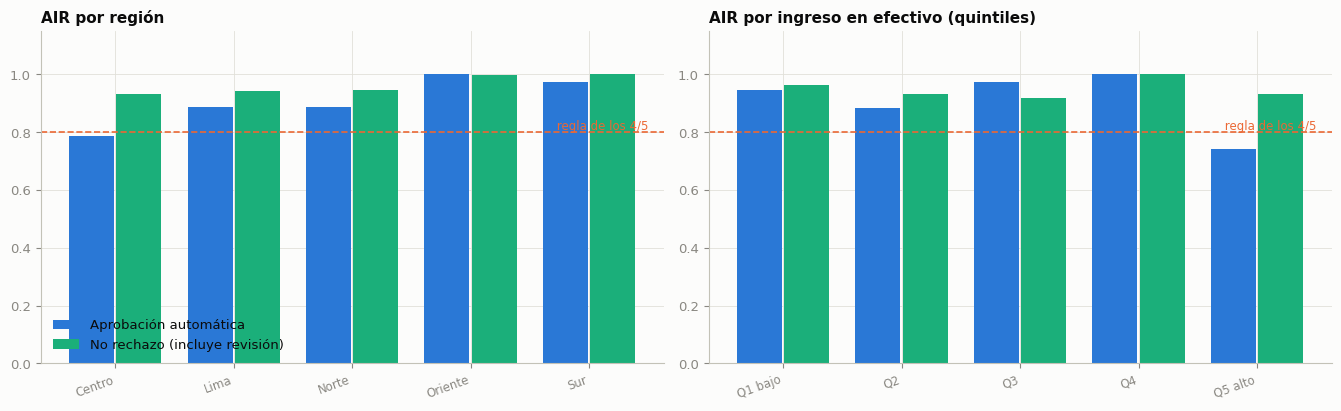

In [7]:
obs = t24[cfg.OUTCOME_FILTER].eq(1).to_numpy()
errores = {n: fr.error_rates_by_group(t24.loc[obs, T], d24.loc[obs, "decision"], g[obs])
           for n, g in grupos.items() if n in ("Región", "Ingreso en efectivo (quintiles)")}
for n, t_ in errores.items():
    print(n); display(t_)
pd.concat(errores).to_csv(cfg.TABLES / "fairness_tasas_error.csv")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
for ax, nombre in zip(axes, ["Región", "Ingreso en efectivo (quintiles)"]):
    a, b = air_auto[nombre].sort_index(), air_no_rechazo[nombre].sort_index()
    x = np.arange(len(a))
    ax.bar(x - 0.2, a["air"], width=0.38, color=BLUE, label="Aprobación automática")
    ax.bar(x + 0.2, b["air"], width=0.38, color=AQUA, label='No rechazo (incluye revisión)')
    ax.axhline(0.80, color=ORANGE, lw=1.2, ls="--")
    ax.text(len(a) - 0.5, 0.80, " regla de los 4/5", color=ORANGE, fontsize=8.5, ha="right", va="bottom")
    ax.set_xticks(x, a.index, rotation=20, ha="right", fontsize=8.5); ax.set_ylim(0, 1.15)
    ax.set_title(f"AIR por {nombre.lower()}")
axes[0].legend(loc="lower left")
fig.tight_layout(); savefig(fig, "fig26_fairness_air"); plt.show()

**Hallazgo 1 · El territorio no queda excluido.** Por región, la aprobación automática va de 46.8% (Centro) a 59.4% (Oriente), con AIR entre 0.79 y 1.00. Oriente y Sur, las regiones que 6.4 identificó con menor default y menor aprobación histórica, son ahora las **más** aprobadas: la política corrige el sesgo territorial de la política histórica en vez de heredarlo.

**Hallazgo 2 · El quintil de mayor informalidad tiene un AIR de 0.74, por debajo de la regla de los 4/5.** No viene de usar la variable (no está en el modelo) sino de dos hechos: ese grupo tiene mayor carga de deuda y su default observado en 2024 fue 19.4% contra 10-15% del resto. Es una diferencia **de riesgo**, no de trato: contando la revisión manual como resultado no adverso, el AIR sube a 0.93, porque el camino previsto para ese segmento es verificar el ingreso, no rechazarlo.

**Hallazgo 3 · Donde hay que poner el ojo es en los buenos del quintil alto.** En las tasas de error, el 46.9% de los clientes buenos del quintil de mayor efectivo no queda aprobado automáticamente, contra 35-43% en el resto. Ese es el costo de inclusión que el caso quiere evitar, y es el que la verificación de ingreso debe recuperar.

## 4. ¿El score es proxy de un atributo sensible?

La prueba: intentar **reconstruir el atributo sensible a partir de los insumos del champion** (buró, DTI post-crédito y ahorro sobre monto, en WOE), con validación cruzada. Si no se puede, el score no es un proxy encubierto.

In [8]:
W_dev = sc.woe_frame(dev, card.binnings, card.variables)
filas = []
for v, etiqueta in fr.SENSIBLES.items():
    r = fr.proxy_strength(W_dev, dev[v])
    filas.append({"atributo": etiqueta, "variable": v, **{k: v2 for k, v2 in r.items()}})
proxy = pd.DataFrame(filas).set_index("atributo")
display(proxy)
proxy.to_csv(cfg.TABLES / "fairness_proxy.csv")
display(fr.score_by_group(card.score(t24), p24, grupos["Región"]))

,variable,tipo,auc_medio_cv,auc_max_cv,r2_cv
atributo,,,,,
Territorio,region,categórica,0.4993,0.5098,NaN
Informalidad del ingreso,cash_income_share,numérica,NaN,NaN,-0.0010
Ruralidad / distancia,distance_to_branch_km,numérica,NaN,NaN,0.0003
Composición del hogar,household_dependents,numérica,NaN,NaN,-0.0017
Edad,age,numérica,NaN,NaN,-0.0013


,solicitudes,score_medio,score_p25,score_mediana,pd_media
grupo,,,,,
Sur,225,605.0178,589.0000,606.0000,0.1393
Oriente,138,604.7899,589.2500,606.0000,0.1415
Norte,243,601.8848,583.0000,603.0000,0.1479
Lima,563,601.7886,583.0000,603.0000,0.1496
Centro,220,601.1409,583.0000,603.0000,0.1519


**Lectura.** Ninguno de los cinco atributos se puede reconstruir con los insumos del champion: región queda en AUC 0.50 (azar) y efectivo, distancia, edad y dependientes en R² de 0.00 o negativo. El score medio por región se mueve apenas 4 puntos (601 a 605) sobre un rango de 110. Dicho de otro modo: **el scorecard no sabe dónde vive ni cómo cobra el solicitante**, y no puede inferirlo.

Esto es importante porque el challenger sí traía esa discusión: en 6.6 se le aplicó el mismo veto, y levantar ese veto le habría dado apenas unos puntos de Gini inestables.

## 5. Riesgos de discriminación indirecta, mitigantes y monitoreo

| Riesgo | Evidencia | Mitigante ya incorporado | Control de monitoreo |
|---|---|---|---|
| La capacidad de pago (DTI) es un proxy parcial de informalidad | AIR 0.74 en el quintil de mayor efectivo | El ingreso en efectivo con ticket alto va a **verificación**, no a rechazo; el AIR de "no rechazo" sube a 0.87 | AIR por quintil de efectivo, mensual, con alerta bajo 0.80 |
| El buró puede estar peor poblado en zonas alejadas | Sin score de buró: 3.3% de las solicitudes | "Sin score" es **revisión con re-consulta**, nunca rechazo automático; WOE neutral en el modelo (6.5) | Participación y aprobación del segmento sin score |
| Territorio | AIR 0.79 en Centro | Región fuera del modelo por diseño; la diferencia viene del perfil de riesgo | AIR territorial del apetito (6.1) |
| Edad | AIR 0.80 en menores de 30 | Edad fuera del modelo; el efecto es indirecto vía relación y ahorro | AIR por tramo de edad |
| El challenger podría reintroducir proxies | Gini apenas cambia al levantar el veto (6.6) | Mismo veto de fairness para todos los modelos | Revisión de fairness obligatoria antes de promover un challenger |

**Dos precauciones que conviene dejar escritas.** Primero, estas comparaciones son **asociaciones, no causalidad**: que el quintil de mayor efectivo tenga menor aprobación no prueba que la política discrimine por informalidad, porque ese grupo también trae más carga de deuda. Segundo, la base no contiene sexo ni etnia, así que el análisis de fairness se limita a los proxies disponibles; en producción la Caja debería medir AIR también sobre los atributos que sí registre.